# Regression: From a Straight Line to Polynomial Curves

**DCS 404 · Data Science and Machine Learning**

---

In the last module we walked the full CRISP-DM loop and, along the way, we casually dropped a
`LinearRegression()` into our modelling phase and let scikit-learn do its thing. It worked. But if I asked you
*how* it worked — how the machine actually chose that particular line out of the infinitely many lines it could
have drawn — you'd have to shrug. Today we fix that.

This module is where we open the hood on our first real algorithm. We'll take regression apart piece by piece:
what the model equation actually says, what assumptions it quietly makes about your data, and — the centrepiece —
the beautiful bit of calculus called **Ordinary Least Squares** that finds the best-fitting line. Then we'll
implement it *from scratch* with nothing but NumPy, check that our hand-rolled version agrees with scikit-learn
to the last decimal, and push beyond straight lines into **polynomial regression**, where we'll meet the most
important tension in all of machine learning: underfitting versus overfitting.

Fair warning: there is more mathematics in this module than in the previous two. Don't let that scare you off.
Every equation is followed by code that *does* the equation, and seeing the two side by side is exactly how the
maths stops being symbols and starts being obvious.

Let's draw some lines.

## How to work through this

Same rhythm as before: run every code cell (`Shift + Enter`), look at the output, *then* read my commentary
underneath. The cells build on each other in order, so if something errors, run from the top.

Two things specific to today. First, the derivation in Section 5 is the one place where I'll ask you to slow
down and follow the algebra line by line — it's maybe ten minutes of careful reading, and it's the ten minutes
that separates "I can call `.fit()`" from "I know what `.fit()` does". Second, this module uses the classic
**Advertising** dataset from the textbook *An Introduction to Statistical Learning*. I've bundled a copy in the
`data/` folder next to this notebook, so everything runs offline.

As always, watch for the places where I stop and ask you to predict something before running the next cell.
That tiny pause is where the learning happens.

## Learning objectives

After completing this module you will be able to:

- Write down and interpret the model equations for simple, multiple, and polynomial regression.
- State the key assumptions of linear regression — linearity in parameters, constant error variance
  (homoscedasticity), no autocorrelation, no perfect multicollinearity, random sampling — and explain why each
  one matters.
- Derive the Ordinary Least Squares estimates of the intercept and slope by minimising the sum of squared
  errors.
- Implement OLS from scratch in NumPy and verify it against scikit-learn's `LinearRegression`.
- Fit and interpret a multiple linear regression, and explain why coefficients change when features are
  modelled together.
- Use `PolynomialFeatures` to fit non-linear relationships with a linear model.
- Diagnose underfitting and overfitting by comparing training and test error as model complexity grows.

## Setup

Run this once. It loads our libraries, sets the same plotting style we've used all course, and reads in the
Advertising dataset. If an import fails, install it with `pip install <package>`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# A consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("deep")
RANDOM_STATE = 0

# Load the Advertising dataset. We look in a couple of likely locations so this runs
# whether you launched Jupyter from the repo root or from inside the notebooks/ folder.
for candidate in [Path("data/Advertising.csv"),
                  Path("notebooks/data/Advertising.csv"),
                  Path("resources/dataset/Advertising.csv")]:
    if candidate.exists():
        ads = pd.read_csv(candidate, index_col=0)
        print(f"Loaded dataset from: {candidate}")
        break
else:
    raise FileNotFoundError("Could not find Advertising.csv. Expected it in a data/ folder next to the notebook.")

print(f"Shape: {ads.shape[0]} markets, {ads.shape[1]} columns")
ads.head()

Loaded dataset from: data/Advertising.csv
Shape: 200 markets, 4 columns


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


Each of the 200 rows is a *market* — think of it as a city where the company sells its product. For every
market we know the advertising budget spent on **TV**, **radio**, and **newspaper** (each in thousands of
dollars) and the resulting **sales** (in thousands of units). The business question writes itself: *if I give
you an advertising budget, how many units will we sell — and which medium is actually doing the work?*

Notice how naturally this fits the CRISP-DM framing from last time. Business understanding: maximise sales by
spending the ad budget wisely. Data understanding: that's what we're about to do. And the target, `sales`, is a
continuous number — so this is a **regression** problem.

---
## 1. What a regression model actually is

Let's fix the vocabulary and notation we'll use for the rest of the course.

**The data.** We observe pairs of inputs and outputs. The input $x$ goes by many names — *feature*, *predictor*,
*covariate*, *independent variable* — and the output $y$ by a few too — *target*, *response*, *dependent
variable*. Pick your favourite; they all mean the same thing.

**The goal.** We want a function that turns inputs into a prediction of the output:

$$y \approx f(x, \beta)$$

where $\beta$ (the Greek letter *beta*) stands for the **parameters** — the numbers the machine must estimate
from the data. Learning, in this chapter, literally means "finding good values of $\beta$".

The simplest choice of $f$ is a straight line, which gives us **simple linear regression** — one input, two
parameters:

$$y = \beta_0 + \beta_1 x$$

Here $\beta_0$ is the **intercept** (the predicted $y$ when $x = 0$) and $\beta_1$ is the **slope** (how much
$y$ changes when $x$ increases by one unit). With several inputs we get **multiple linear regression**:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_d x_d$$

where $d$ is the number of features — for our dataset, $d = 3$ (TV, radio, newspaper).

One subtlety that trips people up, so let's nail it now: a regression method is called **linear** if the
prediction is a linear function *of the parameters* $\beta$ — not necessarily of the inputs $x$. Keep that in
your back pocket; it's the loophole that makes polynomial regression possible later, and it shows up as the very
first assumption in the next section.

---
## 2. First look: does a line even make sense?

Before fitting anything, we look. Always. One scatter plot of sales against each advertising medium tells us
whether a straight-line relationship is even plausible.

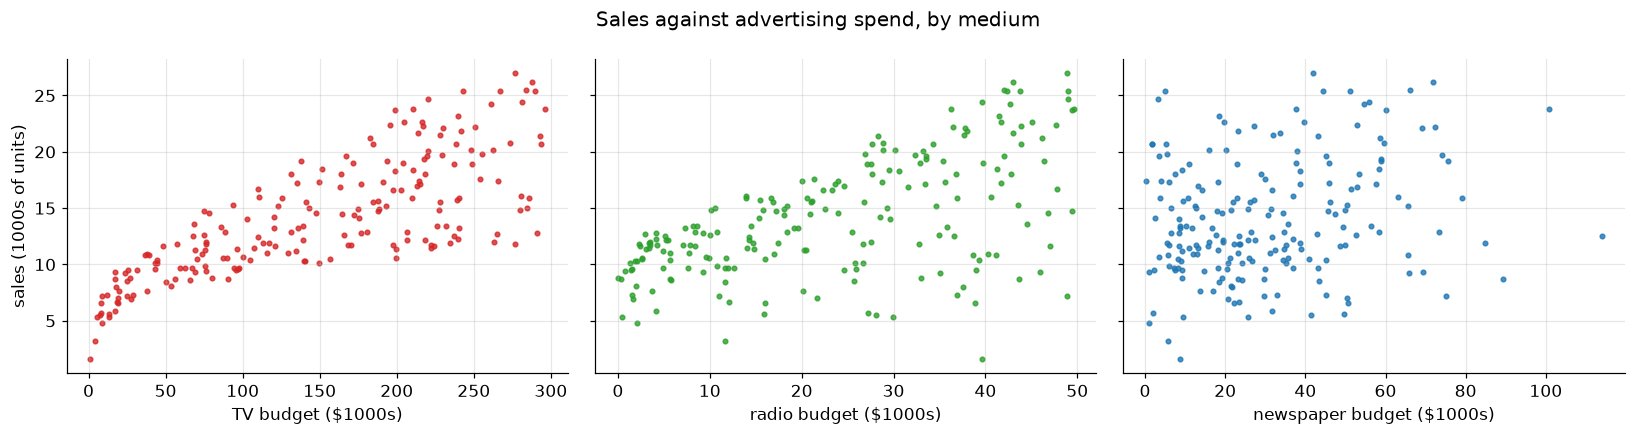

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, medium, colour in zip(axes, ["TV", "radio", "newspaper"], ["tab:red", "tab:green", "tab:blue"]):
    ax.scatter(ads[medium], ads["sales"], color=colour, marker=".", alpha=0.8)
    ax.set_xlabel(f"{medium} budget ($1000s)")
axes[0].set_ylabel("sales (1000s of units)")
fig.suptitle("Sales against advertising spend, by medium")
plt.tight_layout()
plt.show()

Three plots, three different stories. Sales rise sharply and fairly consistently as **TV** spend increases —
a line through that cloud would clearly capture something real. **Radio** shows an upward trend too, though the
cloud is fatter. **Newspaper**, on the other hand, is close to a shapeless blob: whatever newspaper advertising
is doing, it isn't much.

Keep these three pictures in mind. By the end of Section 8 we'll be able to say something precise — and
genuinely surprising — about that newspaper panel.

---
## 3. The rules of the game: assumptions of linear regression

Every model is a bargain: it gives you predictive power in exchange for some assumptions about your data. If the
assumptions hold, the estimates we derive below are provably excellent. If they're badly violated, the model
will still happily produce numbers — they'll just quietly mean less than you think. So before we estimate
anything, let's read the fine print.

### 3.1 The model must be linear *in the parameters*

The response $y$ is a function of inputs $x$ and parameters $\beta$, and the linearity requirement applies to
the $\beta$'s, not the $x$'s. Three examples make the boundary clear:

$$y = \beta_0 + \beta_1 x$$

Linear in both inputs and parameters — obviously fine.

$$y = \beta_0 + \beta_1 x^2$$

*Not* linear in the input (there's an $x^2$), but still linear in the parameters — so this **is** a legitimate
linear regression model. Squaring $x$ before fitting is just a feature transformation.

$$y = \beta_0 + \beta_1^2 x$$

Linear in the input but *not* in the parameter (the $\beta_1$ is squared) — this one **violates** the
assumption and is not a linear regression model.

That middle example is the loophole I promised: transform the features however you like, keep the parameters
linear, and all the machinery of this module still works. Polynomial regression, coming in Section 9, is exactly
this trick.

### 3.2 Errors should have constant variance and no autocorrelation

No line passes through every point; there's always a leftover error (a *residual*) at each observation. The
model assumes those errors have the **same variance everywhere** — a property with the intimidating name
**homoscedasticity**. If instead the errors fan out as $x$ grows (**heteroscedasticity**), the standard
machinery can give misleading parameter estimates.

<center>
<img src="resources/images/homo_heteroscedasticity.png" width="700">

Fig: Homoscedastic errors (constant spread) versus heteroscedastic errors (spread that grows with $x$)
</center>

The errors should also be **independent of each other** — knowing one residual should tell you nothing about
the next. This "no autocorrelation" condition is most famously violated by time-series data, where each
observation leans on the one before it. Our 200 markets are separate places, so we're on safe ground here.

### 3.3 No perfect multicollinearity

This one concerns the inputs: no feature should be an exact (or near-exact) combination of the others. The
classic example: predicting house prices from *length*, *breadth*, **and** *area*. Since

$$\text{area} = \text{length} \times \text{breadth}$$

the third feature adds no new information, and its perfect dependence on the others makes the parameter
estimates unstable — mathematically, the feature matrix loses full rank and the estimation breaks down. The fix
is simple: drop one of the redundant features.

In simple linear regression, with just one input, this assumption can't even be violated. With multiple inputs
it's the first thing to check, and the check is one line of pandas:

In [3]:
# Correlations between the features (and the target, for good measure)
ads.corr().round(2)

,TV,radio,newspaper,sales
TV,1.00,0.05,0.06,0.78
radio,0.05,1.00,0.35,0.58
newspaper,0.06,0.35,1.00,0.23
sales,0.78,0.58,0.23,1.00


No feature pair is anywhere near perfectly correlated, so multiple regression is safe here. But file away one
number from that table: **radio and newspaper correlate at about 0.35**. Markets that spend on radio tend to
also spend on newspaper. That innocent-looking 0.35 is going to explain a mystery in Section 8.

### 3.4 Observations should be randomly sampled

The data should be a random sample from the population you care about. If you're modelling house prices for a
city but only collected houses from the one convenient neighbourhood, no amount of clever estimation will fix
that. And you need more observations than parameters — you can't pin down four unknowns with three data points.

### 3.5 So how do we actually find the parameters?

Assumptions read, bargain accepted. Now the real question: given 200 markets, what values of $\beta_0$ and
$\beta_1$ should we pick? There are two classic families of answer:

- **Least Squares Estimation** — choose the parameters that minimise the sum of squared errors. This family
  includes Ordinary Least Squares (our topic), plus weighted and generalised variants for when the error
  assumptions above are violated.
- **Maximum Likelihood Estimation** — a probabilistic framing: choose the parameters that make the observed
  data most probable. A beautiful idea, and one you'll meet properly later in the course; for linear regression
  with normally distributed errors it actually lands on the *same answer* as least squares.

We'll take the least-squares road. It's the one scikit-learn drives on.

---
## 4. The best line: what "best" means

Look at the TV panel again, now with a fitted line drawn through it:

<center>
<img src="resources/images/simple_linear_regression.png" width="620">

Fig: A regression line through the sales-vs-TV cloud. Each vertical segment is one residual.
</center>

For each market $i$, the line makes a prediction

$$\hat{y}_i = \beta_0 + \beta_1 x_i$$

(read $\hat{y}$ as "y-hat" — the hat always means *estimated*). The actual observed value is

$$y_i = \beta_0 + \beta_1 x_i + \epsilon_i$$

where $\epsilon_i$ is the **residual** or error: the vertical distance between the point and the line,
$\epsilon_i = y_i - \hat{y}_i$. Some residuals are positive (point above the line), some negative (below), so if
we just summed them, they'd cancel and a terrible line could score zero. The standard fix: square each residual
before adding. That gives the **Sum of Squared Errors** (also called the Residual Sum of Squares):

$$\text{SSE} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 = \sum_{i=1}^{n}\big(y_i - (\beta_0 + \beta_1 x_i)\big)^2$$

Read this as a machine: feed in a candidate $(\beta_0, \beta_1)$, get out one number measuring how badly that
line fits. In machine learning we call such a machine a **loss function** (or objective function). "Best line"
now has a precise meaning — *the $(\beta_0, \beta_1)$ that makes SSE as small as possible.* This principle is
**Ordinary Least Squares (OLS)**.

Here's the stroke of luck that makes everything tractable: because SSE is a sum of squares, plotting it against
the two parameters gives a smooth bowl — a **convex** surface with exactly one lowest point.

<center>
<img src="resources/images/convex_cost_function.png" width="680">

Fig: The SSE loss surface is a convex bowl — one minimum, no false bottoms.
</center>

And calculus tells us exactly how to find the bottom of a bowl: the slope there is zero. So we take the partial
derivative of SSE with respect to each parameter, set both to zero, and solve. Two equations, two unknowns.
Let's do it.

---
## 5. The derivation: ten minutes of honest calculus

This is the slow-down section. Nothing here is beyond first-year calculus — the power rule, the chain rule, and
the fact that the derivative of a sum is the sum of the derivatives. To reduce clutter I'll drop the summation
index; every $\sum$ below runs over the $n$ samples, $i = 1$ to $n$.

### 5.1 Partial derivative with respect to $\beta_0$

$$\frac{\partial\,\text{SSE}}{\partial \beta_0}
  = \sum \frac{\partial}{\partial \beta_0}\big(y_i - (\beta_0 + \beta_1 x_i)\big)^2
  = \sum 2\big(y_i - (\beta_0 + \beta_1 x_i)\big)(-1)
  = -2\sum\big(y_i - (\beta_0 + \beta_1 x_i)\big) \tag{1}$$

(The power rule brings the 2 down; the chain rule contributes the $-1$, the derivative of the inside with
respect to $\beta_0$.)

### 5.2 Partial derivative with respect to $\beta_1$

Same moves, except the chain rule now contributes $-x_i$, because $\beta_1$ is multiplied by $x_i$:

$$\frac{\partial\,\text{SSE}}{\partial \beta_1}
  = \sum 2\big(y_i - (\beta_0 + \beta_1 x_i)\big)(-x_i)
  = -2\sum x_i\big(y_i - (\beta_0 + \beta_1 x_i)\big) \tag{2}$$

### 5.3 Set both to zero and solve

**From equation (1):** divide both sides by $-2$ and push the sum through the bracket:

$$\sum y_i - n\beta_0 - \beta_1 \sum x_i = 0$$

(Summing the constant $\beta_0$ over $n$ samples gives $n\beta_0$; $\beta_1$ slides outside its sum.) Isolate
$\beta_0$ and divide by $n$ — and recognise that a sum divided by $n$ is just a mean:

$$\beta_0 = \bar{y} - \beta_1 \bar{x}$$

Lovely — but useless on its own, since it contains the still-unknown $\beta_1$. So we substitute it into the
second equation.

**From equation (2):** divide by $-2$, substitute $\beta_0 = \bar{y} - \beta_1\bar{x}$, and group like terms:

$$\sum x_i\big((y_i - \bar{y}) - \beta_1(x_i - \bar{x})\big) = 0$$

Push the sum through, slide $\beta_1$ out, and rearrange:

$$\beta_1 = \frac{\sum x_i (y_i - \bar{y})}{\sum x_i (x_i - \bar{x})}$$

That's a perfectly correct answer, but you'll almost never see it written that way. A short algebraic fact —
that $\sum(y_i - \bar{y}) = 0$ and $\sum(x_i - \bar{x}) = 0$, so subtracting $\bar{x}$ inside the left factor
changes nothing — lets us rewrite it in the symmetric form every textbook uses. (Try proving the equivalence
yourself: expand $\sum(x_i-\bar{x})(y_i-\bar{y})$ and watch the extra term vanish.)

### 5.4 The result

Putting hats on to mark them as estimates:

$$\boxed{\;\hat{\beta}_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}
\qquad\qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}\;}$$

Pause and admire what just happened. We asked "which of the infinitely many lines minimises the squared error?"
and calculus handed back a *formula* — compute $\hat{\beta}_1$ from means and deviations, substitute to get
$\hat{\beta}_0$, done. No searching, no iterating. (Enjoy it while it lasts: for most models later in the course
no closed-form solution exists, and we'll have to walk downhill step by step — that's *gradient descent*, a
story for another module.)

---
## 6. OLS from scratch

Formulas are one thing; code you wrote yourself is belief. The two boxed equations translate into about four
lines of NumPy.

In [4]:
def ols_fit(x, y):
    """Estimate simple linear regression parameters by Ordinary Least Squares.

    Implements:  b1 = sum((x - x_mean)(y - y_mean)) / sum((x - x_mean)^2)
                 b0 = y_mean - b1 * x_mean
    """
    x_mean, y_mean = x.mean(), y.mean()
    b1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
    b0 = y_mean - b1 * x_mean
    return b0, b1


b0_tv, b1_tv = ols_fit(ads["TV"], ads["sales"])
print(f"TV model:  sales = {b0_tv:.4f} + {b1_tv:.4f} x TV")

TV model:  sales = 7.0326 + 0.0475 x TV


Two numbers, straight from the formulas. And they *mean* something concrete: with zero TV spend we'd expect to
sell about 7,030 units ($\hat{\beta}_0 \approx 7.03$, in thousands), and every extra \$1,000 of TV advertising
buys roughly 47.5 more units sold ($\hat{\beta}_1 \approx 0.0475$).

Let's fit all three mediums and draw the lines we've earned.

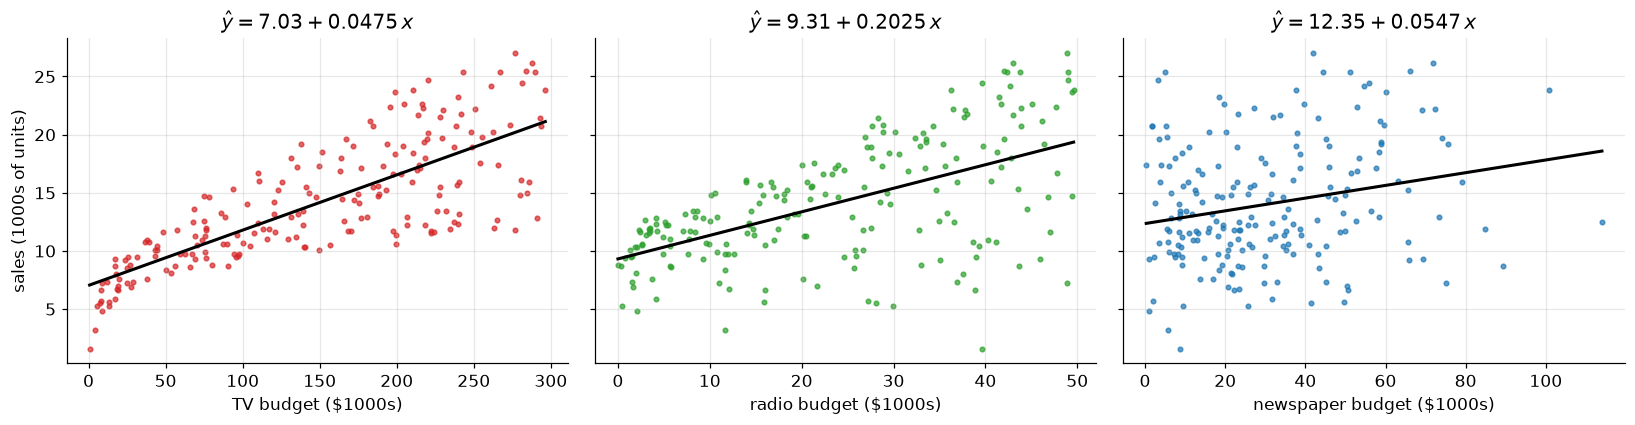

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, medium, colour in zip(axes, ["TV", "radio", "newspaper"], ["tab:red", "tab:green", "tab:blue"]):
    b0, b1 = ols_fit(ads[medium], ads["sales"])
    ax.scatter(ads[medium], ads["sales"], color=colour, marker=".", alpha=0.7)
    xs = np.linspace(ads[medium].min(), ads[medium].max(), 100)
    ax.plot(xs, b0 + b1 * xs, color="black", linewidth=2)
    ax.set_xlabel(f"{medium} budget ($1000s)")
    ax.set_title(f"$\\hat{{y}} = {b0:.2f} + {b1:.4f}\\,x$")
axes[0].set_ylabel("sales (1000s of units)")
plt.tight_layout()
plt.show()

Three simple regressions, one per medium, each fitted with nothing but our four-line function:

- **TV:** $\hat{\beta}_0 \approx 7.03$, $\hat{\beta}_1 \approx 0.048$. A tight fit — the line genuinely
  summarises the cloud.
- **Radio:** $\hat{\beta}_0 \approx 9.31$, $\hat{\beta}_1 \approx 0.20$. The steepest slope of the three: per
  \$1,000 spent, radio is associated with about 200 extra units. But look at the scatter around the line — much
  noisier than TV.
- **Newspaper:** $\hat{\beta}_0 \approx 12.35$, $\hat{\beta}_1 \approx 0.055$. A positive slope, so taken alone,
  newspaper spending *does* look mildly useful. Hold that thought until Section 8.

One more picture before we move on. In Section 3 we assumed errors have constant variance — and this is our
first chance to actually check an assumption instead of just reciting it. A **residual plot** (residuals against
predicted values) makes the check visual: if the assumption holds, we should see a formless horizontal band.

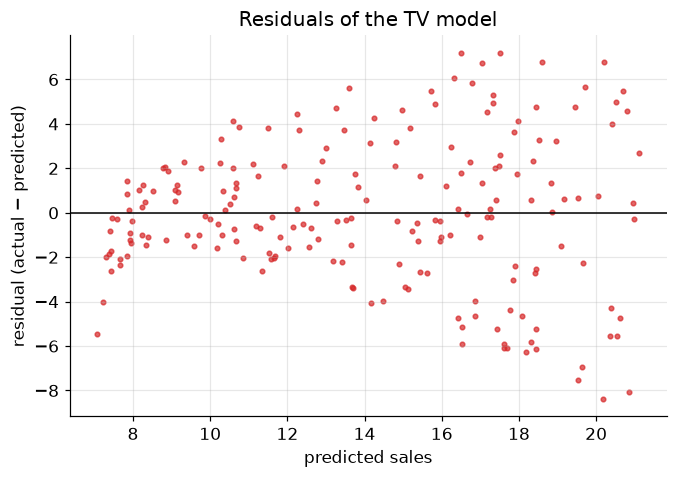

In [6]:
y_hat = b0_tv + b1_tv * ads["TV"]
residuals = ads["sales"] - y_hat

plt.scatter(y_hat, residuals, color="tab:red", marker=".", alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("predicted sales")
plt.ylabel("residual (actual $-$ predicted)")
plt.title("Residuals of the TV model")
plt.show()

Interesting — not quite the formless band we hoped for. The residuals are pinched together at the left and
fan out to the right: the model's errors are *larger* in high-spend markets. That's mild **heteroscedasticity**,
live and in the wild, exactly the pattern from the right-hand panel of the figure in Section 3.2. It isn't
severe enough to sink our analysis, but a careful statistician would note it — and this is precisely why we
state assumptions up front: so we know what to go and check.

---
## 7. Sanity check: does scikit-learn agree?

Whenever you implement an algorithm by hand, verify it against a trusted implementation. If the numbers match,
you've almost certainly understood the algorithm; if they don't, you've found a bug or a misunderstanding —
either way, you learn something.

In [7]:
sk_model = LinearRegression()
sk_model.fit(ads[["TV"]], ads["sales"])

print("            our OLS      scikit-learn")
print(f"intercept   {b0_tv:.6f}    {sk_model.intercept_:.6f}")
print(f"slope       {b1_tv:.6f}    {sk_model.coef_[0]:.6f}")

            our OLS      scikit-learn
intercept   7.032594    7.032594
slope       0.047537    0.047537


Identical, to the last decimal. That's because `LinearRegression` *is* Ordinary Least Squares — the same
minimise-the-squared-error principle, solved by efficient linear algebra rather than our explicit formula.
Every time you've called `.fit()` on a linear model, this is what was happening inside. It isn't magic; it's
Section 5.

---
## 8. Multiple linear regression: the mediums, together

Three separate simple regressions is three separate half-truths: each one credits its own medium with all the
sales, ignoring whatever the other two budgets were doing in the same market. The honest model considers them
together:

$$\text{sales} = \beta_0 + \beta_1 \cdot \text{TV} + \beta_2 \cdot \text{radio} + \beta_3 \cdot \text{newspaper}$$

Each coefficient now answers a sharper question: *how much do sales change per extra \$1,000 on this medium,
holding the other two fixed?* The OLS principle is unchanged — minimise the SSE — only now the bowl lives in
four dimensions and the closed-form solution comes from matrix algebra (the elegant
$\hat{\boldsymbol\beta} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$, for the curious). We'll
let scikit-learn handle that part and keep our energy for interpreting the result.

And because we now know better than to grade a model on its own training data — that was a headline lesson of
the workflow module — we'll split off a test set first.

In [8]:
X = ads[["TV", "radio", "newspaper"]]
y = ads["sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

multi = LinearRegression()
multi.fit(X_train, y_train)

coefs = pd.DataFrame({"coefficient": multi.coef_}, index=X.columns)
print(f"intercept: {multi.intercept_:.3f}")
coefs.round(4)

intercept: 2.995


,coefficient
TV,0.0446
radio,0.1965
newspaper,-0.0028


Read the newspaper row twice. In its simple regression (Section 6), newspaper had a healthy positive slope of
about $0.055$. Modelled *together with* TV and radio, its coefficient collapses to roughly zero — the model is
telling us that once you know a market's TV and radio budgets, the newspaper budget adds essentially nothing.

So why did newspaper look useful on its own? Remember the correlation of about **0.35 between radio and
newspaper** we filed away in Section 3.3. Markets that spend on radio also tend to spend on newspaper. Radio
genuinely drives sales; newspaper just tags along, basking in radio's reflected glory. The simple regression
couldn't tell the difference — the multiple regression can, and that ability to *hold other variables fixed* is
exactly why we bother with it. (This is also multicollinearity's gentler cousin in action: the features aren't
correlated enough to break the model, just enough to fool one-variable-at-a-time analysis.)

Does modelling the mediums together actually predict better? Let's score both models on the held-out test set,
with the same metrics we met last module.

In [9]:
# Simple model: TV only, fitted on the same training split for a fair fight
simple = LinearRegression().fit(X_train[["TV"]], y_train)

results = {}
for name, model, feats in [("TV only", simple, ["TV"]),
                           ("TV + radio + newspaper", multi, list(X.columns))]:
    pred = model.predict(X_test[feats])
    results[name] = {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R^2": r2_score(y_test, pred),
    }

pd.DataFrame(results).T.round(3)

,MAE,RMSE,R^2
TV only,2.505,3.192,0.676
TV + radio + newspaper,1.362,2.098,0.860


No contest. The multiple regression cuts the TV-only model's MAE nearly in half (2.5 down to 1.4) and lifts
$R^2$ from 0.68 to 0.86 — the three budgets together explain about 86% of the variation in sales across
markets. Not bad for a model whose entire brain is four numbers.

The business translation writes itself: put marginal budget into radio and TV, and stop paying for newspaper
ads. *That* is a finding someone will pay for, and it took a 200-row CSV and a model from the 1800s.

---
## 9. When a straight line isn't enough: polynomial regression

Everything so far assumed the truth is a line (or a plane). The real world often disagrees — growth curves
saturate, trajectories arc, seasons oscillate. Time to cash in the loophole from Section 3.1.

A polynomial of degree two in $x$ is

$$y = \beta_0 + \beta_1 x + \beta_2 x^2$$

Look closely: it's *not linear in $x$* (there's an $x^2$), but it *is linear in the parameters* — each $\beta$
enters plainly, no squares, no products of betas. So here's the trick: treat $x^2$ as just **another feature**.
Manufacture a new column equal to $x^2$, hand the model two input columns instead of one, and fit an ordinary
linear regression. Every drop of machinery from Sections 4–7 applies unchanged. This is **polynomial
regression**: new features, same algorithm.

With several original features the transformation also creates cross-terms. Two features $x_1, x_2$ at degree
two become $1,\ x_1,\ x_2,\ x_1 x_2,\ x_1^2,\ x_2^2$ — giving the model

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_1 x_2 + \beta_4 x_1^2 + \beta_5 x_2^2$$

Scikit-learn packages the manufacturing step as
[`PolynomialFeatures`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html).

To watch it work, we'll manufacture a dataset where *we* know the truth: points from a sine curve plus random
noise, mimicking real measurements (imperfect instruments, calibration error, plain bad luck). Because we know
the true curve, we can judge exactly how well each model recovers it — a luxury real data never grants.

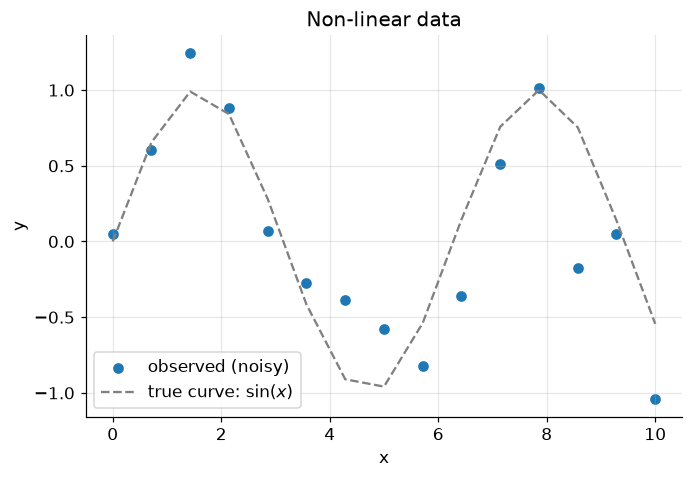

In [10]:
X_FROM, X_TO, N_POINTS = 0, 10, 15

rng = np.random.default_rng(RANDOM_STATE)
x_poly = np.linspace(X_FROM, X_TO, N_POINTS)
y_true = np.sin(x_poly)                                  # the hidden truth
y_poly = y_true + rng.normal(scale=0.4, size=N_POINTS)   # what we actually observe

X_poly = x_poly.reshape(-1, 1)   # sklearn expects a 2-D feature array

plt.scatter(x_poly, y_poly, color="tab:blue", label="observed (noisy)")
plt.plot(x_poly, y_true, color="grey", linestyle="--", label="true curve: $\\sin(x)$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Non-linear data")
plt.legend()
plt.show()

Before running the next cell, predict: what will a plain straight-line fit do with this?

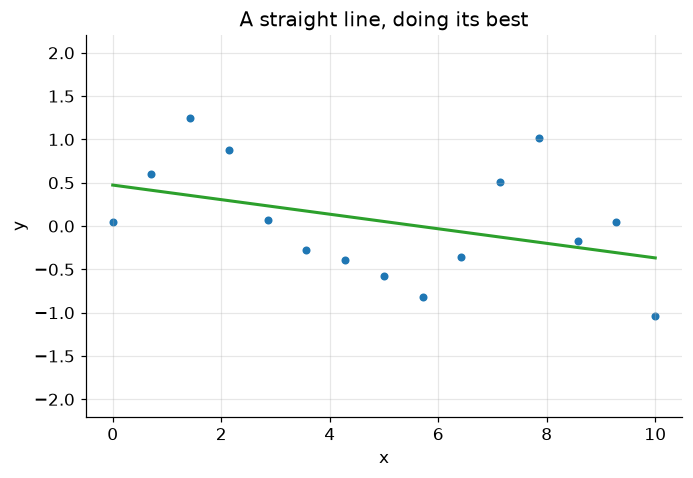

In [11]:
def plot_fit(model, transformer=None, ax=None, title=None):
    """Scatter the data and draw a model's prediction curve over a fine grid."""
    ax = ax or plt.gca()
    grid = np.linspace(X_FROM, X_TO, 300).reshape(-1, 1)
    grid_features = transformer.transform(grid) if transformer else grid
    ax.scatter(x_poly, y_poly, color="tab:blue", s=18)
    ax.plot(grid, model.predict(grid_features), color="tab:green", linewidth=2)
    ax.set_ylim(-2.2, 2.2)
    if title:
        ax.set_title(title)


straight = LinearRegression().fit(X_poly, y_poly)
plot_fit(straight, title="A straight line, doing its best")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

About as useful as you guessed. The line has no vocabulary for waves — no setting of two parameters can bend
it. The model isn't badly *trained*; it's badly *chosen*. Its family of possible shapes simply doesn't contain
anything resembling the data. We say such a model **underfits**.

So let's grow the family. Same `LinearRegression`, but fed polynomial features of increasing degree:

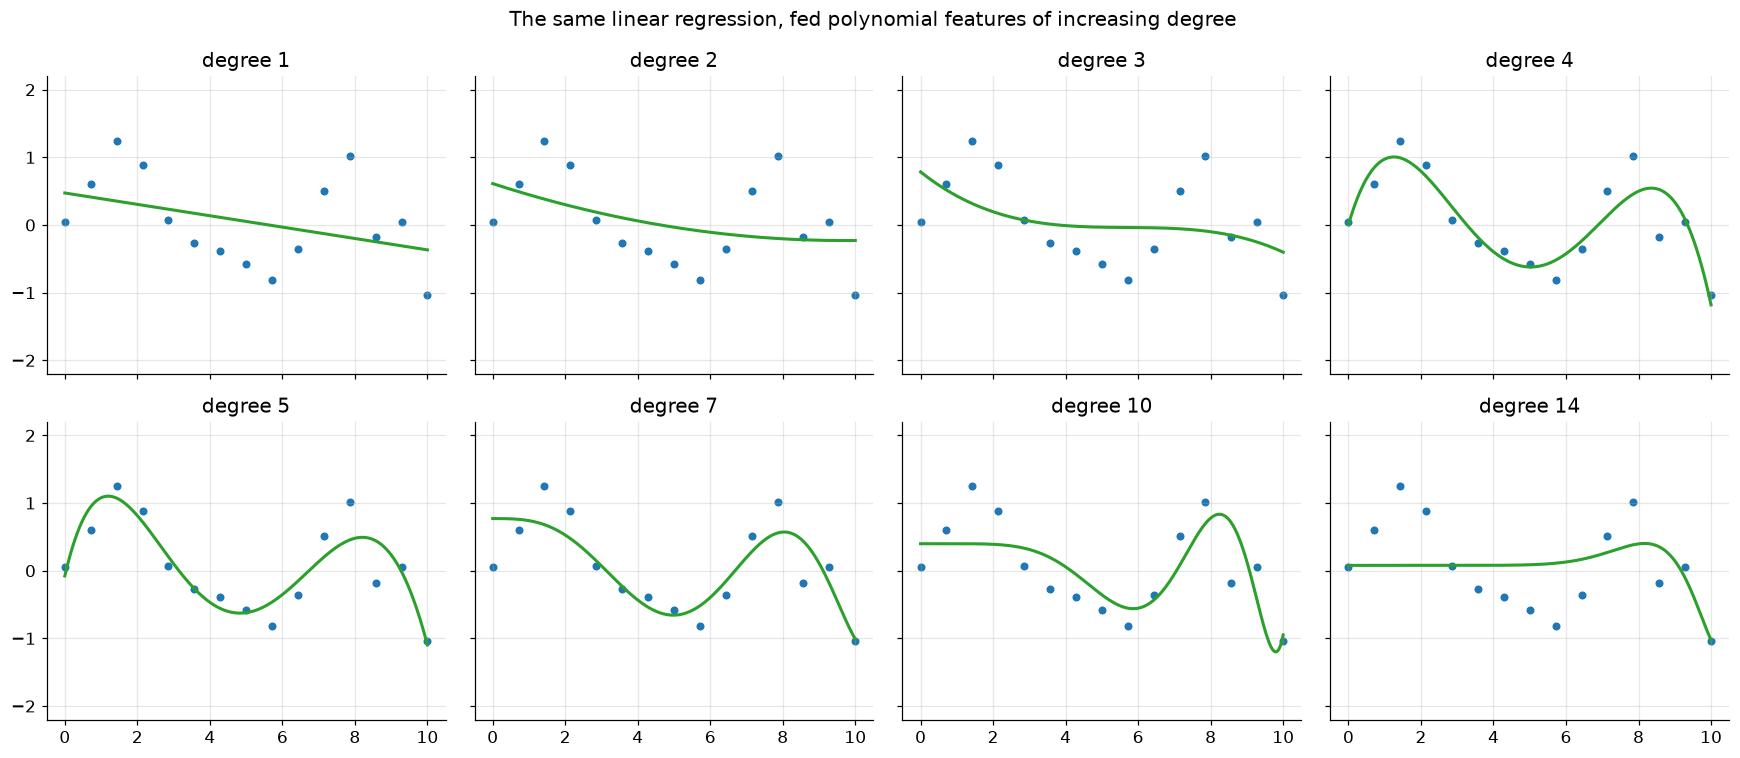

In [12]:
degrees = [1, 2, 3, 4, 5, 7, 10, 14]

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)

poly_models = {}
for ax, degree in zip(axes.ravel(), degrees):
    transformer = PolynomialFeatures(degree=degree)
    X_transformed = transformer.fit_transform(X_poly)   # manufacture x, x^2, ..., x^degree
    model = LinearRegression().fit(X_transformed, y_poly)
    poly_models[degree] = (model, transformer)
    plot_fit(model, transformer, ax=ax, title=f"degree {degree}")

fig.suptitle("The same linear regression, fed polynomial features of increasing degree")
plt.tight_layout()
plt.show()

Watch the story unfold left to right, top to bottom:

- **Degrees 1–3** can't bend enough — still underfitting. (Degree 3 manages a half-hearted S-curve, but a sine
  wave needs more.)
- **Degrees 4–5** find the wave. These are honest approximations of the true sine curve.
- **Degrees 7–14** have capacity to spare, and they spend it on exactly the wrong thing: chasing individual
  noisy points. By degree 14 the curve has 15 parameters — one for each of our 15 observations — so it can
  thread through *every single point*, wiggling frantically and snaking far away from the true curve in
  between.

Here's the trap in that picture: measured on the training points, degree 14 has the *lowest* error of all eight
models — essentially zero. Every extra degree can only reduce training error, because a degree-$n$ polynomial
contains every polynomial below it. If training error were the judge, maximum wiggle would always win. But we
know the truth here is a smooth sine wave — the extra wiggle is the model memorising *noise*, and it will
backfire the moment we ask about a new $x$. That failure mode is **overfitting**, and it is the single most
important pathology in machine learning.

---
## 10. Underfitting, overfitting, and the U-shaped curve

We already own the right diagnostic tool — we built it into our workflow last module. *Judge the model on data
it hasn't seen.* Let's split our 15 points into train and test (10 points to fit on, 5 held back as the exam),
fit every degree from 1 to 12 on the training points only, and track both errors as complexity grows.

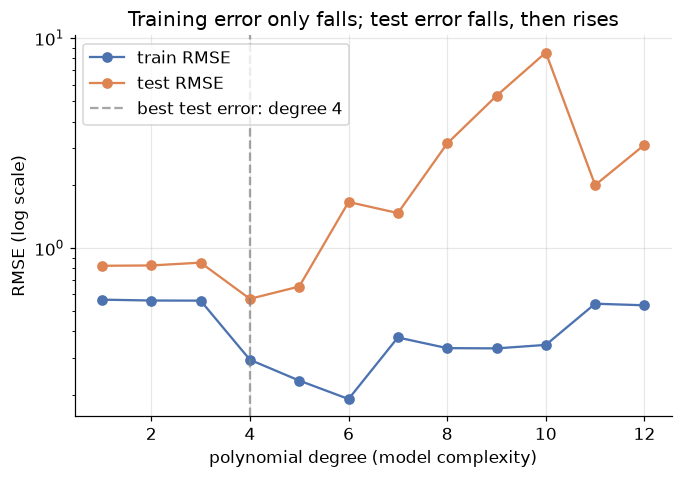

,train RMSE,test RMSE
degree,,
1,0.567,0.822
2,0.561,0.825
3,0.561,0.851
4,0.293,0.572
5,0.233,0.655
6,0.191,1.654
7,0.374,1.466
8,0.333,3.144
9,0.332,5.303


In [13]:
Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_poly, y_poly, test_size=0.3, random_state=RANDOM_STATE)

records = []
for degree in range(1, 13):
    transformer = PolynomialFeatures(degree=degree)
    model = LinearRegression().fit(transformer.fit_transform(Xp_train), yp_train)

    rmse = lambda X_, y_: np.sqrt(mean_squared_error(y_, model.predict(transformer.transform(X_))))
    records.append({"degree": degree,
                    "train RMSE": rmse(Xp_train, yp_train),
                    "test RMSE": rmse(Xp_test, yp_test)})

curve = pd.DataFrame(records).set_index("degree")

best_degree = curve["test RMSE"].idxmin()

# From degree 9 up, 10+ parameters fit 10 training points exactly, so train RMSE is
# essentially zero -- we clip it to keep the log-scale plot happy.
plt.plot(curve.index, curve["train RMSE"].clip(lower=1e-3), marker="o", label="train RMSE")
plt.plot(curve.index, curve["test RMSE"], marker="o", label="test RMSE")
plt.axvline(best_degree, color="grey", linestyle="--", alpha=0.7,
            label=f"best test error: degree {best_degree}")
plt.yscale("log")
plt.xlabel("polynomial degree (model complexity)")
plt.ylabel("RMSE (log scale)")
plt.title("Training error only falls; test error falls, then rises")
plt.legend()
plt.show()

curve.round(3).head(10)

This picture is worth the whole module — arguably the whole course. Two curves, two completely different
stories:

- **Training error** (blue) only goes down. More complexity always helps the model flatter itself — and from
  degree 9 it hits rock bottom at *essentially zero*, because a model with ten parameters can thread ten
  training points exactly. Perfect memorisation.
- **Test error** (orange) traces a **U-shape**: it falls while added complexity captures real structure, bottoms
  out at a modest degree, then climbs — sometimes explosively — as the model starts memorising noise.

The vocabulary, one more time, now with pictures attached:

- **Underfitting** (left of the U): the model is too simple to capture the real pattern. Both training and test
  error are high. Remedy: more capacity, better features.
- **Overfitting** (right of the U): the model is so flexible it learns the noise. Training error is superb, test
  error is terrible — and the gap between the two curves is your warning light.
- **Generalisation** (the bottom of the U): the actual goal. Not the model that best fits the data you have, but
  the one that will best fit the data you *don't* have yet.

Every model family you'll meet from here on — decision trees, random forests, neural networks — has its own
complexity dial, and every one of them traces this same U. The names change; the trade-off never does.

---
## 11. Your turn

Add cells below each exercise and have a go. The first two are quick; the last three are where the ideas get
into your fingers.

**Exercise 1 — Radio, by hand.**
Use our `ols_fit` function on `radio` vs `sales`, then verify the two parameters against scikit-learn's
`LinearRegression`, as we did for TV in Section 7. Write the fitted equation in a markdown cell.

**Exercise 2 — Spend the money.**
Using the multiple regression from Section 8: predict sales for a market with a \$100k TV budget, \$30k radio
budget, and \$20k newspaper budget (mind the units — budgets are in thousands). According to the model, which
single medium gives the most extra sales per additional \$1,000?

**Exercise 3 — Break the assumptions on purpose.**
Add a fake feature `total = TV + radio + newspaper` to the multiple regression from Section 8 and refit. What
happens to the coefficients? Which assumption from Section 3 did you just violate?

**Exercise 4 — Back to the students.**
Load last module's `data/student-mat.csv` (remember `sep=";"`) and fit a simple linear regression of `G3` on
`G1` from scratch with `ols_fit`. Plot the data with the fitted line and interpret both parameters in plain
English: what does the slope say about first-period versus final grades?

**Exercise 5 — Move the U.**
In Section 10, change the noise level (`scale=0.4`) to `0.1` and rerun, then to `0.8` and rerun. Watch where
the best-test-error degree lands each time. What does noise do to the amount of model complexity you can
afford? Try changing `N_POINTS` from 15 to 100 as well — does more data let you get away with higher degrees?

---
## 12. If you remember nothing else

1. A regression model is a function $y \approx f(x, \beta)$, and "learning" means estimating the parameters
   $\beta$ from data. "Linear" means linear *in the parameters* — the features themselves are fair game for
   transformation.

2. Linear regression comes with assumptions: linearity in parameters, constant error variance
   (homoscedasticity), no autocorrelation, no perfect multicollinearity, random sampling. State them, then
   *check* them — a residual plot is the five-second check for the variance one.

3. Ordinary Least Squares defines "best line" as the one minimising the sum of squared errors, and because that
   loss is a convex bowl, calculus yields closed-form solutions:
   $\hat{\beta}_1 = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sum(x_i-\bar{x})^2}$ and
   $\hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$.

4. Scikit-learn's `LinearRegression` is exactly this. You've now written it yourself and matched it to six
   decimal places — `.fit()` is no longer a black box.

5. Multiple regression coefficients answer "holding everything else fixed" — which is why newspaper's effect
   evaporated once radio was in the room. Correlated features make one-variable-at-a-time analysis lie.

6. Polynomial regression is linear regression fed manufactured features ($x^2, x^3, \dots$). New features, same
   algorithm.

7. Training error only ever falls as complexity grows; test error traces a U. Underfitting on the left,
   overfitting on the right, generalisation at the bottom. Judge models only on data they haven't seen.

8. Every model family you'll ever meet has a complexity dial and the same U-shaped trade-off waiting for you.

---
## 13. Further reading and glossary

### Further reading

- *An Introduction to Statistical Learning*, [Chapter 3](https://www.statlearning.com/) — the definitive gentle
  treatment of linear regression, and the home of our Advertising dataset.
- MIT's [lecture notes on simple linear regression](http://www.mit.edu/~6.s085/notes/lecture3.pdf) — Section 3.1
  walks the same least-squares derivation with additional statistical detail.
- scikit-learn's [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
  and [`PolynomialFeatures`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)
  documentation — the practical references for everything we used today.
- The scikit-learn worked example on
  [underfitting vs. overfitting](https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html)
  — the same experiment as our Section 10, with cross-validation added.

### Glossary

| Term | Meaning |
|---|---|
| Regression | Predicting a continuous numeric target from input features. |
| Parameter / coefficient ($\beta$) | A number the model learns from data; in linear regression, an intercept and one slope per feature. |
| Intercept ($\beta_0$) | Predicted value of $y$ when all features are zero. |
| Slope ($\beta_1$) | Change in predicted $y$ per one-unit increase in a feature (others held fixed). |
| Residual / error ($\epsilon$) | Difference between an observed value and the model's prediction, $y_i - \hat{y}_i$. |
| SSE / RSS | Sum of squared errors — the loss function OLS minimises. |
| Ordinary Least Squares (OLS) | Estimating parameters by minimising the SSE; has a closed-form solution. |
| Convex function | A bowl-shaped function with a single minimum — no false bottoms for optimisation to get stuck in. |
| Homoscedasticity | Errors have constant variance across all observations; its violation is heteroscedasticity. |
| Autocorrelation | Correlation between errors of different observations (common in time series). |
| Multicollinearity | One feature being an (almost) exact combination of others, destabilising the estimates. |
| Multiple linear regression | Linear regression with several input features. |
| Polynomial regression | Linear regression on manufactured polynomial features ($x^2$, $x^3$, cross-terms, …). |
| Underfitting | Model too simple to capture the real pattern — high error on train *and* test. |
| Overfitting | Model so flexible it memorises noise — low training error, high test error. |
| Generalisation | Performing well on unseen data; the actual goal of machine learning. |